# 02 — Propensity Score Estimation and IPW

**Goal.** This notebook estimates the propensity score and uses it to build an inverse probability weighting estimator.

The propensity score is:

$$
e(X) = P(A=1 \mid X).
$$

## Methods covered

1. Simulate confounded observational data;
2. Estimate the propensity score with logistic regression;
3. Check overlap between treated and untreated groups;
4. Estimate the ATE using inverse probability weighting;
5. Compare naive, adjusted regression, and IPW estimators.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, LogisticRegression

FIG_DIR = Path("figures")
RES_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def summarize_estimates(estimates, true_ate):
    return pd.DataFrame([
        {
            "Estimator": name,
            "Estimate": value,
            "True ATE": true_ate,
            "Bias": value - true_ate,
            "Absolute error": abs(value - true_ate),
        }
        for name, value in estimates.items()
    ])

## 1. Simulate observational data

The data are generated from a known model, so the true ATE is known.

In [10]:
def simulate_confounded_data(n=5000, tau=2.0, beta0=1.0, gamma=1.5,
                             treatment_intercept=-0.2, treatment_slope=1.3,
                             noise_sd=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, n)
    p_treat = sigmoid(treatment_intercept + treatment_slope * X)
    A = rng.binomial(1, p_treat, n)
    eps = rng.normal(0, noise_sd, n)
    Y = beta0 + tau * A + gamma * X + eps
    return pd.DataFrame({"X": X, "A": A, "Y": Y, "true_propensity": p_treat})

TRUE_ATE = 2.0
df = simulate_confounded_data(n=5000, tau=TRUE_ATE, seed=RANDOM_SEED)
df.head()

,X,A,Y,true_propensity
0,0.304717,1,2.411366,0.548876
1,-1.039984,0,-1.309001,0.174801
2,0.750451,1,4.138870,0.684728
3,0.940565,1,4.693989,0.735505
4,-1.951035,0,-2.551557,0.060862


## 2. Estimate the propensity score

We fit a logistic regression model:

$$
P(A=1 \mid X) = \text{logit}^{-1}(\alpha_0 + \alpha_1X).
$$

In [11]:
ps_model = LogisticRegression(solver="lbfgs")
ps_model.fit(df[["X"]], df["A"])
df["estimated_propensity"] = ps_model.predict_proba(df[["X"]])[:, 1]
df[["X", "A", "true_propensity", "estimated_propensity"]].head()

,X,A,true_propensity,estimated_propensity
0,0.304717,1,0.548876,0.540093
1,-1.039984,0,0.174801,0.174622
2,0.750451,1,0.684728,0.674551
3,0.940565,1,0.735505,0.725350
4,-1.951035,0,0.060862,0.062127


## 3. Compare true and estimated propensity scores

In real data, the true propensity score is unknown. Here, it is available because we simulated the data.

Correlation between true and estimated propensity scores: 1.0000


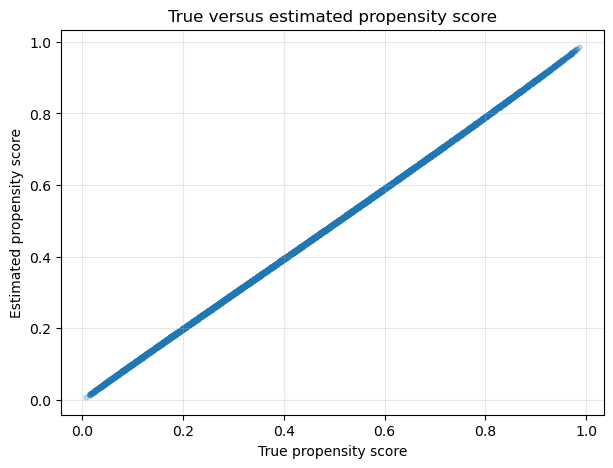

In [12]:
corr = np.corrcoef(df["true_propensity"], df["estimated_propensity"])[0, 1]
print(f"Correlation between true and estimated propensity scores: {corr:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(df["true_propensity"], df["estimated_propensity"], alpha=0.25, s=12)
plt.xlabel("True propensity score")
plt.ylabel("Estimated propensity score")
plt.title("True versus estimated propensity score")
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "02_true_vs_estimated_propensity.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Overlap diagnostics

A good causal comparison requires sufficient overlap: treated and untreated individuals should exist for similar values of the propensity score.

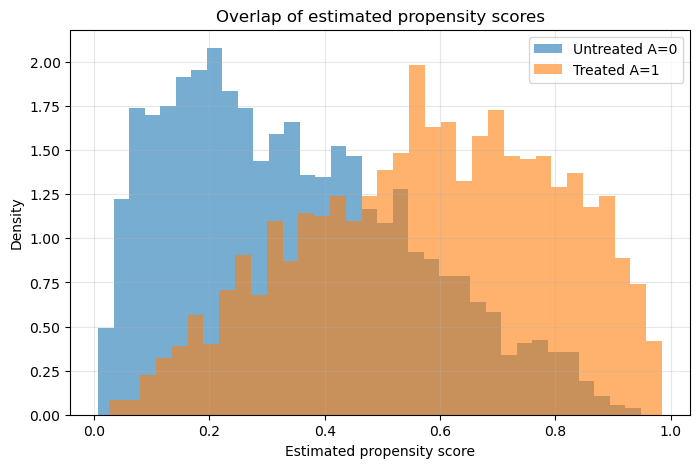

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["A"] == 0, "estimated_propensity"], bins=35, alpha=0.6, label="Untreated A=0", density=True)
plt.hist(df.loc[df["A"] == 1, "estimated_propensity"], bins=35, alpha=0.6, label="Treated A=1", density=True)
plt.xlabel("Estimated propensity score")
plt.ylabel("Density")
plt.title("Overlap of estimated propensity scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "02_propensity_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. IPW estimation

The Horvitz-Thompson IPW estimator for the ATE is:

$$
\widehat{ATE}_{IPW}
=
\frac{1}{n}\sum_{i=1}^{n}
\left(
\frac{A_iY_i}{\hat e(X_i)}
-
\frac{(1-A_i)Y_i}{1-\hat e(X_i)}
\right).
$$

We also compute the Hájek normalized version, which often has lower variance in finite samples.

In [14]:
def ipw_ate(df, ps_col="estimated_propensity", outcome_col="Y", treatment_col="A"):
    A = df[treatment_col].to_numpy()
    Y = df[outcome_col].to_numpy()
    e = np.clip(df[ps_col].to_numpy(), 1e-6, 1 - 1e-6)
    ate_ht = np.mean(A * Y / e - (1 - A) * Y / (1 - e))
    mu1_hajek = np.sum(A * Y / e) / np.sum(A / e)
    mu0_hajek = np.sum((1 - A) * Y / (1 - e)) / np.sum((1 - A) / (1 - e))
    ate_hajek = mu1_hajek - mu0_hajek
    return ate_ht, ate_hajek

ipw_ht, ipw_hajek = ipw_ate(df)
print(f"IPW Horvitz-Thompson ATE: {ipw_ht:.4f}")
print(f"IPW Hajek ATE: {ipw_hajek:.4f}")

IPW Horvitz-Thompson ATE: 1.9943
IPW Hajek ATE: 1.9924


## 6. Compare estimators

In [15]:
naive_diff = df.loc[df["A"] == 1, "Y"].mean() - df.loc[df["A"] == 0, "Y"].mean()
reg_naive = LinearRegression().fit(df[["A"]], df["Y"])
reg_adjusted = LinearRegression().fit(df[["A", "X"]], df["Y"])

estimates = {
    "Naive difference in means": naive_diff,
    "Naive regression Y~A": reg_naive.coef_[0],
    "Adjusted regression Y~A+X": reg_adjusted.coef_[0],
    "IPW Horvitz-Thompson": ipw_ht,
    "IPW Hajek": ipw_hajek,
}
summary = summarize_estimates(estimates, TRUE_ATE)
summary

,Estimator,Estimate,True ATE,Bias,Absolute error
0,Naive difference in means,3.427128,2.0,1.427128,1.427128
1,Naive regression Y~A,3.427128,2.0,1.427128,1.427128
2,Adjusted regression Y~A+X,1.974069,2.0,-0.025931,0.025931
3,IPW Horvitz-Thompson,1.994309,2.0,-0.005691,0.005691
4,IPW Hajek,1.992356,2.0,-0.007644,0.007644


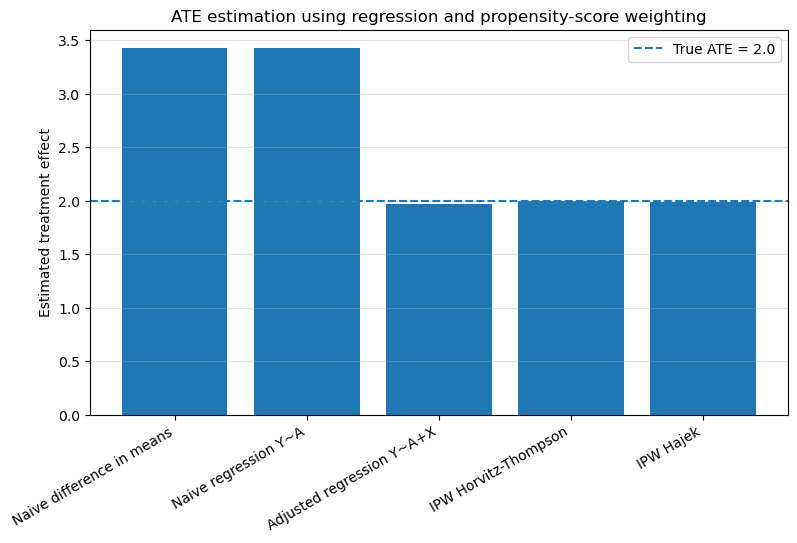

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(summary["Estimator"], summary["Estimate"])
plt.axhline(TRUE_ATE, linestyle="--", label=f"True ATE = {TRUE_ATE}")
plt.ylabel("Estimated treatment effect")
plt.title("ATE estimation using regression and propensity-score weighting")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(FIG_DIR / "02_ate_estimator_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interpretation

The propensity score estimates the probability of receiving treatment given the covariate. IPW uses this score to reweight the sample and create a pseudo-population where treatment is less dependent on the confounder.

## Key message

When the propensity score model is correctly specified and there is good overlap, IPW can reduce confounding bias and recover an estimate close to the true causal effect.